In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from analysis.extract import load_positions
import os
from numpy.typing import NDArray


def acf(x, nlags=40, fft=False):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    denom = np.dot(x, x)

    if denom == 0:
        return np.ones(nlags + 1)

    corr = np.correlate(x, x, mode='full')[x.size - 1:]
    return corr[: nlags + 1] / denom


In [5]:
CSV_PATH = 'output_droplet_tracking/csv_files'
data = load_positions(os.path.join(CSV_PATH,'for_2.1_droplets.csv'))[0]
x = data[6][:,0]
y = data[6][:,1]




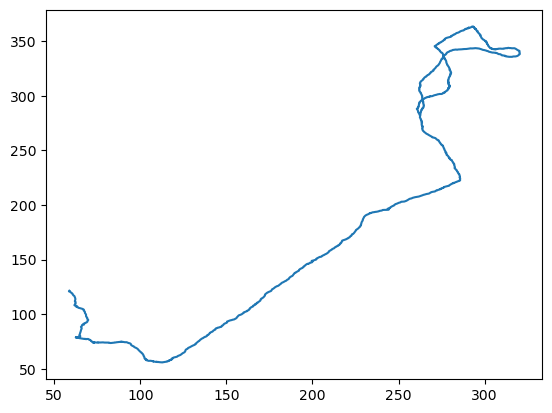

In [ ]:
plt.plot(x,y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def vacf_model(t, A, tau, B, omega, phi):
    return A * np.exp(-t/tau) * (1 + B * np.cos(omega * t + phi))

def calculate_curve(vacf, t_array):
    p0 = [1.0, 100.0, 0.1, 0.05, 0.0]
    
    # Fit using the full array of lag times, not just a scalar dt
    params, cov = curve_fit(vacf_model, t_array, vacf, p0=p0, maxfev=10000)
    
    A, tau, B, omega, phi = params
    print(f"tau = {tau:.3f}")
    print(f"omega = {omega:.3f}")
    return tau, omega

def calculate_quantities(x, name: str, dt: float = 1.0):
    # 1. Velocity time series
    vx = np.diff(x) / dt
    
    # 2. Velocity autocorrelation (500 lags means 501 points returned)
    vacf = acf(vx, nlags=500, fft=True)
    
    # 3. Create the actual lag time array for curve fitting
    t_array = np.arange(len(vacf)) * dt
    tau, omega = calculate_curve(vacf, t_array)
    
    # 4. Fourier transform & Frequencies
    S = np.fft.fft(vacf)
    freq = np.fft.fftfreq(len(vacf), dt)
    
    # Integral timescale (using updated np.simps or np.trapezoid in newer numpy versions)
    tau_c = np.trapz(vacf, dx=dt) 
    print(f"tau_c = {tau_c:.3f}")
    
    # 5. Plotting (Positive frequencies only)
    mask = freq > 0
    plt.figure()
    plt.title(name)
    plt.plot(freq[mask], np.abs(S[mask]), label='Power Spectrum')
    
    # Multi-line LaTeX annotation anchored relative to the plot axes (top right)
    plt.annotate(
        text=fr'$\tau_c$ = {tau_c:.2f}' + '\n' + fr'$\tau$ = {tau:.2f}' + '\n' + fr'$\omega$ = {omega:.2f}',
        xy=(0.75, 0.85),          # Coordinates: 75% right, 85% up
        xycoords='axes fraction', # Uses 0-1 scale relative to the bounding box
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3) # Adds a readable background
    )
    
    plt.xlabel("Frequency")
    plt.ylabel("Power")
    
    plt.show()


In [ ]:

import numpy as np
from scipy.optimize import curve_fit

def vacf_model(t, A, tau, B, omega, phi):
    return A * np.exp(-t/tau) * (1 + B*np.cos(omega*t + phi))

# t = lag times
# vacf = normalized VACF
def calculate_curve(vacf,t):
    p0 = [1.0, 100.0, 0.1, 0.05, 0.0]

    params, cov = curve_fit(vacf_model, t, vacf, p0=p0)

    A, tau, B, omega, phi = params
    return tau,omega
   

def calculate_quantities(x:NDArray,name:str,dt:float = 1.0):
    '''
    calculates 1 - velocity auto-correlation
    calculates 1 - velocity auto-correlation
    calculates 1 - velocity auto-correlation
    
    '''
    # velocity time series
    vx = np.diff(x)/dt
    # velocity autocorrelation
    vacf = acf(vx, nlags=500, fft=True)
    tau,omega = calculate_curve(vacf,dt)
    # Fourier transform
    S = np.fft.fft(vacf)

    # frequencies
    freq = np.fft.fftfreq(len(vacf),dt)
    
    tau_c = np.trapz(vacf, dx=dt)
    print(tau_c)
    
    # positive frequencies only
    mask = freq > 0
    plt.title(name)
    plt.plot(freq[mask], np.abs(S[mask]))
    plt.annotate(
    text=fr'$\tau$ = {tau} and $\omega$ = {omega}',  # Use fr'...' for f-string + LaTeX
    xy=(22, 11),                                     # The point to annotate
    xycoords='data',
    fontsize=12
    )
    # plt.annotate(text = rf'$\tau_c$ = {tau_c} \n $\tau$ = {tau} \n $\omega$ = {omega}',xycoords=(22,11))
    plt.xlabel("Frequency")
    plt.ylabel("Power")
    
    plt.show()


tau = 196.089
omega = 0.053
tau_c = 94.168


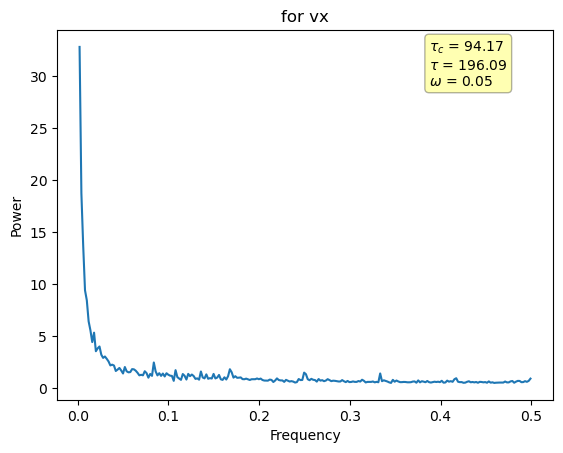

tau = 225.741
omega = 0.014
tau_c = 154.540


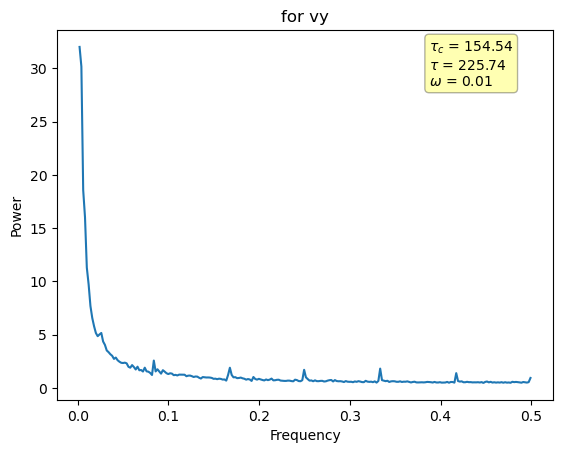

In [45]:
calculate_quantities(x,name='for vx')
calculate_quantities(y,name='for vy')



In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_vacf_semilog(tau, vacf, title="VACF Semi-Log"):
    """
    Semi-log plot:
    exponential decay appears approximately straight.

    Parameters
    ----------
    tau : array
        Lag times
    vacf : array
        Velocity autocorrelation function
    """

    mask = vacf > 0

    plt.figure(figsize=(6,4))
    plt.semilogy(tau[mask], vacf[mask], lw=2)

    plt.xlabel(r"Lag time $\tau$")
    plt.ylabel(r"$C_v(\tau)$")
    plt.title(title)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()



def plot_vacf_loglog(tau, vacf, title="VACF Log-Log"):
    """
    Log-log plot:
    power-law decay appears approximately straight.

    Parameters
    ----------
    tau : array
        Lag times
    vacf : array
        Velocity autocorrelation function
    """

    mask = vacf > 0

    plt.figure(figsize=(6,4))
    plt.loglog(tau[mask], vacf[mask], lw=2)

    plt.xlabel(r"Lag time $\tau$")
    plt.ylabel(r"$C_v(\tau)$")
    plt.title(title)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
def calculate_quantities(x, name: str, dt: float = 1.0):
    # 1. Velocity time series
    vx = np.diff(x) / dt
    
    # 2. Velocity autocorrelation (500 lags means 501 points returned)
    vacf = acf(vx, nlags=500, fft=True)
    tau = np.arange(len(vacf)) * dt

    plot_vacf_semilog(tau,vacf , title=f"{name} VACF Semi-Log")
    plot_vacf_loglog(tau, vacf, title=f"{name} VACF Log-Log")


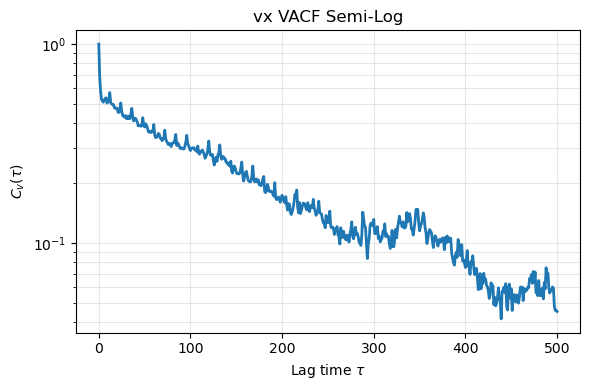

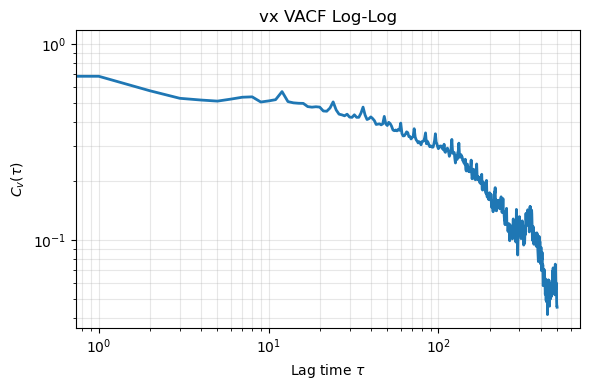

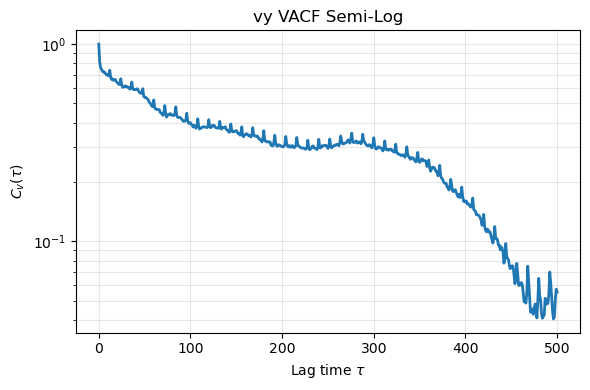

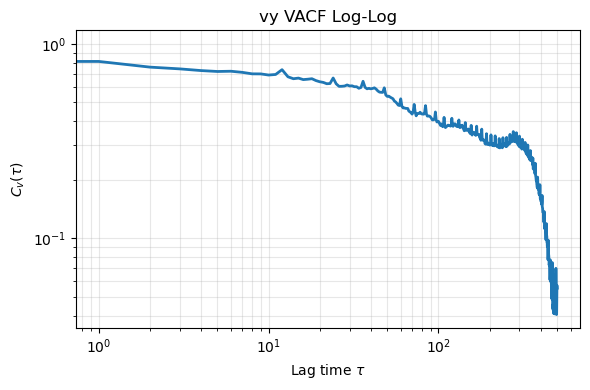

In [48]:
calculate_quantities(x=x,name='vx')
calculate_quantities(x=y,name='vy')


In [ ]:

def run_analysis(
    base_dir: str = './output_droplet_tracking',
    output_dir: str = "./output",
    dt: float = 0.2,
    msd_fit_fraction: float = 0.4,
    msd_minimum_pairs: int | None = None,
    vacf_max_fit_fraction: float | None = None,
    orient_max_fit_fraction: float | None = None,
):
    """
    Run ONLY the analysis / plotting on existing CSVs.

    Parameters
    ----------
    base_dir   : str   — folder (or parent of sub-folders) containing CSVs.
                            Each sub-folder with a .csv file will be processed.
    output_dir : str   — where to save plots and results.txt
    dt         : float — time step between frames (default 1/30 fps)

    Example
    -------
    >>> pipeline = DropletPipeline()
    >>> # For simulation output:
    >>> pipeline.run_analysis("simulation data", "./output_sim")
    >>> # For tracking output:
    >>> pipeline.run_analysis("output_droplet_tracking/csv_files", "./output")
    """
    from analysis.main import run_post_processing
    print("=" * 60)
    print("  RUNNING ANALYSIS ONLY")
    print("=" * 60)
    run_post_processing(
        base_dir=base_dir,
        output_dir=output_dir,
        dt=dt,
        msd_fit_fraction=msd_fit_fraction,
        msd_minimum_pairs=msd_minimum_pairs,
        vacf_max_fit_fraction=vacf_max_fit_fraction,
        orient_max_fit_fraction=orient_max_fit_fraction,
    )

for i in [0.3,0.4,0.5]:
    print(f'for lag % = {i}')
    run_analysis(msd_fit_fraction = i)


for lag % = 0.3
  RUNNING ANALYSIS ONLY
No CSV found in ./output_droplet_tracking/annotated_videos
Processing : for_2&4ul_droplets
  Total paths found    : 24
  Consistent paths     : 4
  Ensemble average (N) : 4
MSD exponent alpha = 1.285995527699619
for_2&4ul_droplets PSD exponent beta_x = 0.6071301478660375

for_2&4ul_droplets PSD exponent beta_y = 0.6615037596985804

Saved results for : for_2&4ul_droplets
Processing : for_2.1_droplets
  Total paths found    : 8
  Consistent paths     : 4
  Ensemble average (N) : 4
MSD exponent alpha = 1.7224606994948088
for_2.1_droplets PSD exponent beta_x = 0.7445383221673546

for_2.1_droplets PSD exponent beta_y = 0.737621834790774

Saved results for : for_2.1_droplets
Processing : for_2.2_droplets
  Total paths found    : 10
  Consistent paths     : 6
  Ensemble average (N) : 6
MSD exponent alpha = 1.4247071813141314
for_2.2_droplets PSD exponent beta_x = 0.559518571176173

for_2.2_droplets PSD exponent beta_y = 0.561441350774522

Saved results 

In [ ]:
import scipy
import statsmodels

print("SciPy:", scipy.__version__)
print("SciPy path:", scipy.__file__)

print("Statsmodels:", statsmodels.__version__)
print("Statsmodels path:", statsmodels.__file__)


SciPy: 1.17.1
SciPy path: /home/prana/.local/lib/python3.12/site-packages/scipy/__init__.py
Statsmodels: 0.14.1+dfsg
Statsmodels path: /usr/lib/python3/dist-packages/statsmodels/__init__.py


In [1]:
from analysis.extract import load_positions
from analysis.compute import compute_msd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.typing import NDArray
import numpy as np

import statsmodels.api as sm


In [2]:
def fit_msd_power_law(
    msd: NDArray[np.floating],
    fit_fraction: float = 0.3
):
    """
    Fit MSD ~ tau^alpha on a log-log scale.

    Parameters
    ----------
    msd : ndarray
        MSD values.
    fit_fraction : float
        Fraction of early-time MSD points used for fitting.

    Returns
    -------
    alpha
    alpha_err
    r2
    fit_line_full
    model
    """

    tau = np.arange(1, len(msd) + 1)

    max_fit = max(1, int(fit_fraction * len(tau)))

    tau_fit = tau[:max_fit]
    msd_fit = msd[:max_fit]

    mask = (tau_fit > 0) & (msd_fit > 0)

    log_tau_fit = np.log10(tau_fit[mask])
    log_msd_fit = np.log10(msd_fit[mask])

    X = sm.add_constant(log_tau_fit)

    model = sm.OLS(
        log_msd_fit,
        X
    ).fit()

    alpha = model.params[1]
    alpha_err = model.bse[1]
    r2 = model.rsquared

    fit_line_full = np.full_like(msd, np.nan, dtype=float)

    fit_line_full[:len(log_tau_fit)] = (
        10 ** model.predict(X)
    )

    return (
        alpha,
        alpha_err,
        r2,
        fit_line_full,
        model
    )


In [ ]:
def individual_analysis(path:Path,dt):

    positions_consistent, total_paths, consistent_paths = load_positions(path)
    d_keys = list(positions_consistent.keys())
    
    fig,ax = plt.subplots()
    
    ensemble_msd = np.zeros_like(compute_msd(r=positions_consistent[d_keys[0]],lag_fraction=0.3))
    tau = np.arange(1, len(ensemble_msd) + 1)
    
    for i in range(consistent_paths):
        msd = compute_msd(r=positions_consistent[d_keys[i]],lag_fraction=0.3)
        
        
        alpha, alpha_err, r2, fit_line, model = (
            fit_msd_power_law(msd, fit_fraction=0.3)
        )
        ensemble_msd += msd
        
        tau_seconds = tau * dt
        
        ax.set_title(f'for 2.1 droplet for frames {msd.shape[0]}')
        
        ax.set_xlabel("Lag time τ (s)")
        ax.set_ylabel("MSD")
        ax.loglog(tau_seconds, msd,label = rf'droplet Id - {d_keys[i]} and its $\alpha = {alpha:.4f}$')
        plt.legend()
        
    ensemble_msd = ensemble_msd /consistent_paths
    
    alpha, alpha_err, r2, fit_line, model = (
            fit_msd_power_law(ensemble_msd, fit_fraction=0.3)
        )
    
    ax.loglog(
    tau,
    ensemble_msd,
    ls = '--',
    linewidth=3,
    label=f'ensemble α={alpha:.3f}'
    )
    plt.legend()


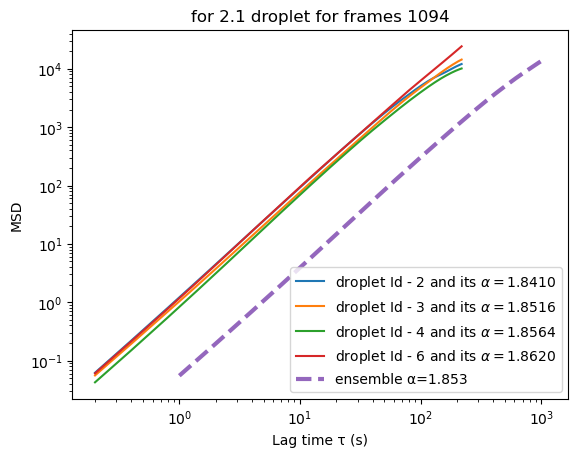

In [ ]:
CSV_PATH = Path("./output_droplet_tracking/csv_files")

file_path = CSV_PATH / 'for_2.1_droplets.csv'
individual_analysis(file_path,dt=0.2)


In [ ]:
positions_consistent, total_paths, consistent_paths = load_positions(file_path)


In [ ]:
list(positions_consistent.keys())[0]


2